# 선형회귀(Linear Regression)

## Machine Learning
명시적으로 규칙을 프로그래밍하지 않고, 데이터로부터 패턴을 학습하여 예측, 판단을 하는 기술

### 전통적 프러그래밍
- 데이터와 규칙을 입력으로 준다.
- 정답이 출력된다.
- e.g. if 가격 > 10000: 비싸다

### 머신러닝
- 데이터와 정답을 입력으로 준다.
- 모델(규칙)이 출력된다.
- 값을 스스로 판단하여 비싼지의 여부를 결정

## 머신러닝의 기본 흐름

1. 데이터 수집
1. 데이터 전처리
1. 학습(훈련) / 테스트(검증) 데이터를 분리
1. 모델 학습
1. 평가
1. 예측

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['axes.unicode_minus'] = False

# matplotlib가 가끔 그래프를 못 그릴때 필요함
%matplotlib inline  

In [7]:
df = pd.read_csv('data/flight.csv')
df.head(3)

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956


In [8]:
df = df.drop(['Unnamed: 0'], axis=1)
df.head(3)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956


## 인코딩(Encoding)
- 범주형(문자열형) 데이터를 의미있는 수치형 데이터로 변환하는 알고리즘

1. Label Encode
- Label을 줄 때 함부로 값을 주면 학습에 영향을 줄 수 있음
- 따라서 규모나 크기가 있는 범주형 (s, m, l, xl, xxl....)
1. Ordinary Encode
1. One-Hot Encode

In [9]:
df_test = pd.DataFrame({
    'color':['Red', 'Bule', 'Green', 'Green', 'Red'],
    'size' : ['S', 'L', 'M', 'S', 'L'],
    'city' : ['Seoul', 'Busan', 'Daugu', 'Busan', 'Seoul'],
    'price' : [100,200,300,140,220]
})

df_test.head()

,color,size,city,price
0,Red,S,Seoul,100
1,Bule,L,Busan,200
2,Green,M,Daugu,300
3,Green,S,Busan,140
4,Red,L,Seoul,220


In [10]:
# 라벨 인코딩 하기

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_test['size_le'] = le.fit_transform(df_test['size'])
df_test

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
# 순서형 인코딩 (pandas를 이용한 방법)
size_map = {'S' : 0, 'M' : 1, 'L' : 2}
df_test['size_ord'] = df_test['size'].map(size_map)
df_test

,color,size,city,price,size_le,size_ord
0,Red,S,Seoul,100,2,0
1,Bule,L,Busan,200,0,2
2,Green,M,Daugu,300,1,1
3,Green,S,Busan,140,2,0
4,Red,L,Seoul,220,0,2


In [ ]:
# 순서형 인코딩 (scikitlearn를 이용한 방법)
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder(categories=[['S', 'M', 'L']])   # 순서를 지정해야함
df_test['size_ord2'] = oe.fit_transform(df_test['size']).astype(int)
df_test

,color,size,city,price,size_le,size_ord,size_ord2
0,Red,S,Seoul,100,2,0,0
1,Bule,L,Busan,200,0,2,2
2,Green,M,Daugu,300,1,1,1
3,Green,S,Busan,140,2,0,0
4,Red,L,Seoul,220,0,2,2


In [ ]:
df_test = df_test.drop(['size_le', 'size_ord', 'size_ord2'], axis=1)


In [ ]:
df_test

,color,size,city,price
0,Red,S,Seoul,100
1,Bule,L,Busan,200
2,Green,M,Daugu,300
3,Green,S,Busan,140
4,Red,L,Seoul,220


In [ ]:
# One-Hot Encoing
df_test_enc = pd.get_dummies(df_test['color'], prefix='color').astype(int)
df_test_enc

,color_Bule,color_Green,color_Red
0,0,0,1
1,1,0,0
2,0,1,0
3,0,1,0
4,0,0,1


In [ ]:
# One-Hot Encoing (Dummy Encoding) -> 선형회귀에서 많이 사용함
df_test_enc = pd.get_dummies(df_test['color'], prefix='color', drop_first=True).astype(int)

,color_Green,color_Red
0,0,1
1,0,0
2,1,0
3,1,0
4,0,1


## 스케일링 (Scaling)

수치형 데이터들은 컬럼들간의 단위가 달라서 학습할때 연산에서 가중치가 적용될 수 있으므로 각 수치들을 평탄화하는 작업이 필요함.

1. Min-Max Scaling(정규화): 범위를 0-1 사이로 변환
1. Standard Scaling(표준화): 평균을 0, 표준편차를 1로 만드는 정규분포 형태로 변환
1. Robust Scaling: (값 - 중앙값) / IQR, 이상치에 영향을 덜 받는 스케일을 적용한다

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

ss = StandardScaler()
ms = MinMaxScaler()
rs = RobustScaler()

# 수치형 데이터들의 컬럼 추출
cols = df.select_dtypes(include='number').columns

# Standard Scaling
df_ss = pd.DataFrame(ss.fit_transform(df[cols]), columns=cols)
df_ss.head()

,duration,days_left,price
0,-1.397531,-1.843875,-0.658068
1,-1.375284,-1.843875,-0.658068
2,-1.397531,-1.843875,-0.657936
3,-1.386407,-1.843875,-0.657980
4,-1.375284,-1.843875,-0.657980


In [ ]:
# Min-Max Scaling
df_ms = pd.DataFrame(ms.fit_transform(df[cols]), columns=cols)
df_ms.head()

,duration,days_left,price
0,0.027347,0.0,0.039749
1,0.030612,0.0,0.039749
2,0.027347,0.0,0.039773
3,0.028980,0.0,0.039765
4,0.030612,0.0,0.039765


In [ ]:
# Robust Scaling
df_rs = pd.DataFrame(rs.fit_transform(df[cols]), columns=cols)
df_rs.head()

,duration,days_left,price
0,-0.972163,-1.086957,-0.039006
1,-0.955032,-1.086957,-0.039006
2,-0.972163,-1.086957,-0.038926
3,-0.963597,-1.086957,-0.038953
4,-0.955032,-1.086957,-0.038953


In [ ]:
# 캘리포니아 집 정보 데이터
df = pd.read_csv('data/california.csv')
df.head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0


In [ ]:
# 학습용, 검증용, Feature(변수), 정답 데이터로 분리하기
from sklearn.model_selection import train_test_split

# 정답열(median house value)만 제거한 feature열들을 별도로 자름
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

display(X.head())   # Feature
display(y.head())   # 정답

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250


0    66900.0
1    80100.0
2    85700.0
3    73400.0
4    65500.0
Name: median_house_value, dtype: float64

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# print(type(X_train))
# print(type(X_test))
# print(type(y_train))
# print(type(y_test))

print(f'훈련데이터: {X_train.shape}')
print(f'검증데이터: {X_test.shape}')

훈련데이터: (13600, 8)
검증데이터: (3400, 8)


In [ ]:
# 스케일 적용하기
# ss = StandardScaler()
rs = RobustScaler()

# ss.fit를 이용하면 직접 공식을 넣을 수 있음
X_train_scaled = rs.fit_transform(X_train)  # fit이 있으면 공식이 들어가있음
X_test_scaled = rs.transform(X_test)    # fit이 없으면 공식이 없음

display(X_train_scaled)
print()
display(X_test_scaled)

# y들은 변형하지 않음

array([[ 0.10817942, -0.11640212, -0.36842105, ...,  0.14072495,
        -0.12962963,  2.29181788],
       [ 0.22427441, -0.1984127 , -0.89473684, ...,  0.35501066,
         0.25308642,  1.67846226],
       [ 0.36675462, -0.44444444, -0.63157895, ..., -0.86993603,
        -0.99691358,  0.7380966 ],
       ...,
       [ 0.08707124, -0.08994709,  0.47368421, ..., -0.44029851,
        -0.62345679, -0.26180036],
       [ 0.37203166, -0.44708995, -1.05263158, ...,  2.26012793,
         1.32716049, -0.20002519],
       [-1.03693931,  0.92592593,  1.21052632, ...,  0.80916844,
         0.42901235, -0.52465397]], shape=(13600, 8))

array([[-0.63060686,  0.93121693, -1.05263158, ...,  1.37206823,
         1.58333333,  0.02743019],
       [ 0.08970976, -0.03703704,  1.21052632, ..., -0.02132196,
         0.01234568,  2.09568513],
       [-0.41424802,  0.72222222, -0.68421053, ...,  1.37526652,
         0.88580247, -0.46123024],
       ...,
       [-0.66490765,  0.8968254 , -0.52631579, ..., -0.54904051,
        -1.13888889, -1.18087213],
       [ 0.02110818, -0.02910053,  0.84210526, ..., -1.05117271,
        -0.99382716,  0.73347148],
       [ 0.06332454, -0.04761905, -0.10526316, ..., -0.98507463,
        -1.01234568, -0.88033063]], shape=(3400, 8))

In [ ]:
# 학습
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print('Weights')
print(model.coef_)

Weights
[-164733.28873408 -162941.83078885   21502.76325771  -15009.22409415
   40025.20665235  -33446.33810785   14627.80780555   87774.22879148]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# 예측하기
y_pred = model.predict(X_test_scaled)

# 평가지표 계산하기
mse = mean_squared_error(y_test, y_pred)
rnse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE(평균 제곱 오차): {mse}')
print(f'RNSE(평균 제곱근 오차): {rnse}')
print(f'MAE(평균 절대 오차): {mae}')
print(f'R2 Score: {r2}')

MSE(평균 제곱 오차): 4634658406.223357
RNSE(평균 제곱근 오차): 68078.32552452621
MAE(평균 절대 오차): 49983.474651229226
R2 Score: 0.6636396350243802


In [ ]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_
}).sort_values('coefficient', ascending=False)

coef_df

,feature,coefficient
7,median_income,87774.228791
4,total_bedrooms,40025.206652
2,housing_median_age,21502.763258
6,households,14627.807806
3,total_rooms,-15009.224094
5,population,-33446.338108
1,latitude,-162941.830789
0,longitude,-164733.288734


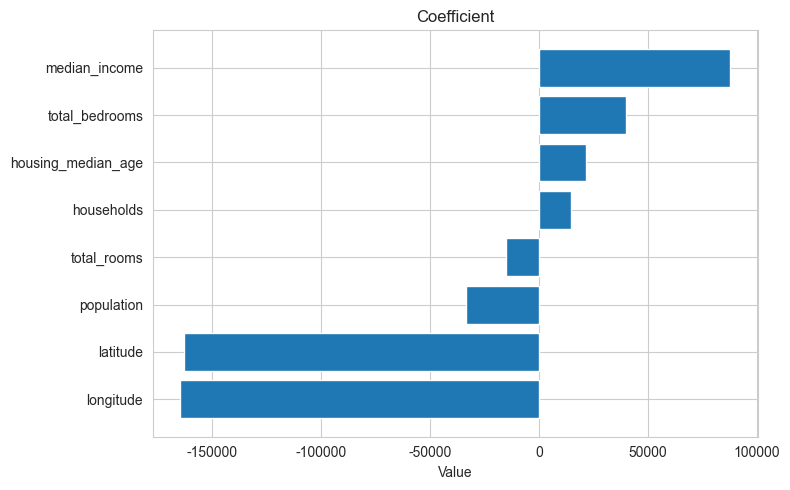

In [ ]:
# 시각화하기
plt.figure(figsize=(8, 5))
plt.barh(coef_df['feature'], coef_df['coefficient'])
plt.title('Coefficient')
plt.gca().invert_yaxis()
plt.xlabel('Value')
plt.tight_layout()
plt.show()

In [ ]:
# 숙제로 안 좋은 영향들을 주는 feature들 제거해서 training 시켜보기